In [2]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

from src.config import Configuration    
CONFIG = Configuration(
    max_bg_samples=200_000
)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Try VPC images

In [ ]:
# import numpy as np

# x_train = np.load("../data/ViolaJones/x_train.npy")
# x_test = np.load("../data/ViolaJones/x_test.npy")


# x = np.concatenate((x_train, x_test), axis=0)

# # np.save("../data/ViolaJones/vpc_faces.npy", x)

In [ ]:
# from pathlib import Path
# import numpy as np
# import matplotlib.pyplot as plt

# no_faces_folder = "../data/ViolaJones/no_faces/vpc"
# output_dir = Path(no_faces_folder)
# output_dir.mkdir(parents=True, exist_ok=True)

# for i, img in enumerate(x):
#     arr = np.asarray(img)

#     # Handle channel-first arrays: (C, H, W) -> (H, W, C)
#     if arr.ndim == 3 and arr.shape[0] in (1, 3) and arr.shape[-1] not in (1, 3):
#         arr = np.moveaxis(arr, 0, -1)

#     # Convert to uint8 image range [0, 255]
#     if arr.dtype != np.uint8:
#         if np.issubdtype(arr.dtype, np.floating):
#             if arr.size > 0 and arr.max() <= 1.0 and arr.min() >= 0.0:
#                 arr = (arr * 255.0).clip(0, 255).astype(np.uint8)
#             else:
#                 arr = arr.clip(0, 255).astype(np.uint8)
#         else:
#             arr = arr.clip(0, 255).astype(np.uint8)

#     # If image has shape (H, W, 1), save as grayscale 2D
#     if arr.ndim == 3 and arr.shape[-1] == 1:
#         arr = arr[:, :, 0]

#     file_path = output_dir / f"no_face_{i:06d}.png"
#     plt.imsave(file_path, arr, cmap="gray" if arr.ndim == 2 else None)

# print(f"Saved {len(x)} images to {output_dir.resolve()}")

# Original dataset passing Open CV model

In [6]:
import cv2

def inspect_image_faces(image_path, face_cascade, scale_factor=1.1, min_neighbors=5, min_size=(24, 24)):
    image = cv2.imread(str(image_path), cv2.IMREAD_COLOR)
    if image is None:
        return None, None, False

    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    faces, reject_levels, level_weights = face_cascade.detectMultiScale3(
        gray,
        scaleFactor=scale_factor,
        minNeighbors=min_neighbors,
        minSize=min_size,
        outputRejectLevels=True,
    )

    # Zip detections with their scores for easy downstream use
    detections = []
    if len(faces):
        for rect, weight in zip(faces, level_weights):
            detections.append({"rect": rect, "confidence": float(weight)})

    has_faces = len(detections) > 0
    return image, detections, has_faces


def image_has_faces(image_path, face_cascade, scale_factor=1.1, min_neighbors=5, min_size=(24, 24)):
    _, _, has_faces = inspect_image_faces(
        image_path,
        face_cascade,
        scale_factor=scale_factor,
        min_neighbors=min_neighbors,
        min_size=min_size,
    )
    return has_faces

In [7]:
import os
cascade_path = os.path.join(CONFIG.cv_haar_cascades, "haarcascade_frontalface_default.xml")
face_cascade = cv2.CascadeClassifier(str(cascade_path))
if face_cascade.empty():
    raise FileNotFoundError(f"Could not load cascade XML: {cascade_path}")


In [11]:
from tqdm import tqdm
import shutil
from maikol_utils.file_utils import list_dir_files, make_dirs

CONFIDENCE_THRESHOLD = 7.5

# Normalize configured output crop size into OpenCV (width, height) tuple
crop_size = (CONFIG.crop_size, CONFIG.crop_size)

# Output folders: images that pass vs fail the detector
passed_dir = os.path.join(CONFIG.faces_original_path, "cv_passed")
failed_dir = os.path.join(CONFIG.faces_original_path, "cv_failed")
make_dirs([passed_dir, failed_dir])

image_paths, _ = list_dir_files(CONFIG.faces_all_path)

passed = []
failed = []
unreadable = []

for img_path in tqdm(image_paths, desc="Processing images"):
    img, detections, has_faces = inspect_image_faces(img_path, face_cascade)

    # Filter low-confidence hits before picking the largest
    confident = [d for d in detections if d["confidence"] >= CONFIDENCE_THRESHOLD]

    if img is None:
        unreadable.append(img_path)
        continue

    if has_faces and confident:
        # Keep only the largest detected face and overwrite output with resized crop
        best = max(confident, key=lambda d: d["rect"][2] * d["rect"][3])
        x, y, w, h = best["rect"]

        face_crop = img[y:y + h, x:x + w]

        if face_crop.size == 0:
            failed.append(img_path)
            shutil.copy2(img_path, os.path.join(failed_dir, os.path.basename(img_path)))
            continue

        interp = cv2.INTER_AREA if face_crop.shape[1] >= crop_size[0] and face_crop.shape[0] >= crop_size[1] else cv2.INTER_CUBIC
        face_crop_resized = cv2.resize(face_crop, crop_size, interpolation=interp)

        out_path = os.path.join(passed_dir, os.path.basename(img_path))
        ok = cv2.imwrite(out_path, face_crop_resized)
        if not ok:
            raise IOError(f"Failed to write cropped face to: {out_path}")

        passed.append(img_path)
    else:
        failed.append(img_path)
        shutil.copy2(img_path, os.path.join(failed_dir, os.path.basename(img_path)))

print(f"Source dir: {CONFIG.faces_all_path}")
print(f"Total candidate images: {len(image_paths)}")
print(f"Passed (>=1 face): {len(passed)}")
print(f"Failed (0 faces): {len(failed)}")
print(f"Unreadable: {len(unreadable)}")
print(f"Passed output (largest-face crops resized to {crop_size}): {passed_dir}")
print(f"Failed output: {failed_dir}")

# Keep lists available for downstream analysis in the notebook
passed_paths = [str(p) for p in passed]
failed_paths = [str(p) for p in failed]
unreadable_paths = [str(p) for p in unreadable]

Processing images: 100%|██████████| 136965/136965 [02:25<00:00, 943.40it/s] 

Source dir: ../data/ViolaJones/face_images/all
Total candidate images: 136965
Passed (>=1 face): 25614
Failed (0 faces): 111351
Unreadable: 0
Passed output (largest-face crops resized to (24, 24)): ../data/ViolaJones/face_images/cv_passed
Failed output: ../data/ViolaJones/face_images/cv_failed


67690

In [12]:
import cv2

for img_path in tqdm(list_dir_files(passed_dir)[0], desc="Flipping images"):
    img = cv2.imread(str(img_path))
    if img is None:
        continue
    flipped = cv2.flip(img, 1)
    out_path = os.path.join(
        passed_dir, 
        f"{os.path.basename(img_path).split('.')[0]}_flipped.{os.path.basename(img_path).split('.')[1]}"
    )
    cv2.imwrite(str(out_path), flipped)

Flipping images: 100%|██████████| 25614/25614 [00:00<00:00, 41945.86it/s]


# Create partition

In [13]:
import numpy as np
CONFIG = Configuration(
    max_bg_samples=500,
    stride=1,
    max_faces=70000
    
)
rng = np.random.default_rng(seed=42)


In [14]:
from maikol_utils.file_utils import list_dir_files


all_faces, n = list_dir_files(CONFIG.faces_passed_path)
print(f"Total images in faces directory: {n}")

all_faces = rng.permutation(all_faces)

test_faces = all_faces[:int(CONFIG.test_size * len(all_faces))]
train_faces = all_faces[int(CONFIG.test_size * len(all_faces)):]
test_faces = rng.choice(test_faces, size=min(len(test_faces), CONFIG.max_faces), replace=False)
train_faces = rng.choice(train_faces, size=min(len(train_faces), CONFIG.max_faces), replace=False)

print(f"Train faces: {len(train_faces)}")
print(f"Test faces: {len(test_faces)}")

Total images in faces directory: 51228
Train faces: 46106
Test faces: 5122


In [15]:
from tqdm import tqdm 
import shutil
import os

for split, paths in [("train", train_faces), ("test", test_faces)]:
    output_dir = CONFIG.faces_train_path if split == "train" else CONFIG.faces_test_path
    for img_path in tqdm(paths, desc=f"Copying {split} images"):
        shutil.copy2(img_path, os.path.join(output_dir, os.path.basename(img_path)))
    print(f"Copied {len(paths)} images to {output_dir}")

Copying train images: 100%|██████████| 46106/46106 [00:00<00:00, 49435.56it/s]


Copied 46106 images to ../data/ViolaJones/face_images/train


Copying test images: 100%|██████████| 5122/5122 [00:00<00:00, 49981.33it/s]

Copied 5122 images to ../data/ViolaJones/face_images/test


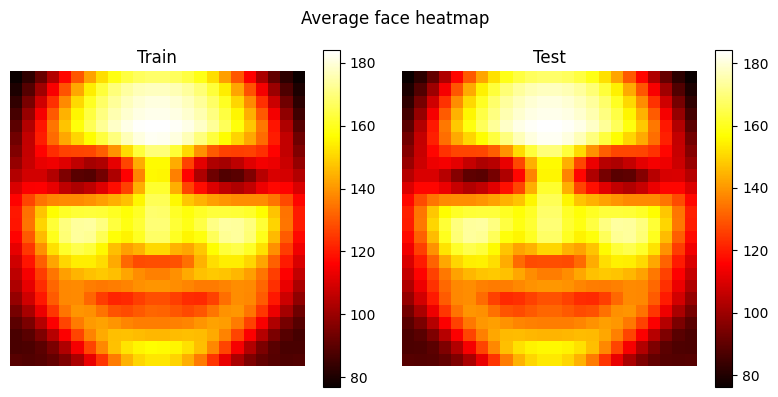

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

from maikol_utils.file_utils import list_dir_files

train_files, _ = list_dir_files(CONFIG.faces_test_path)
test_files, _ = list_dir_files(CONFIG.faces_train_path)

def avg_faces(paths):
    stack = np.stack([np.array(Image.open(p).convert("L")) for p in paths])
    return stack.mean(axis=0)

train_avg = avg_faces(train_files)
test_avg  = avg_faces(test_files)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
for ax, avg, title in zip(axes, [train_avg, test_avg], ["Train", "Test"]):
    im = ax.imshow(avg, cmap="hot")
    ax.set_title(title)
    ax.axis("off")
    plt.colorbar(im, ax=ax)

plt.suptitle("Average face heatmap")
plt.tight_layout()
plt.show()

# No faces dataset

In [10]:
import fiftyone as fo
import fiftyone.zoo as foz
from fiftyone import ViewField as F
from maikol_utils.file_utils import load_json, list_dir_files


# to_keep_labels = load_json(CONFIG.dataset_classes_path)

# # Download dataset without faces
# fo.config.dataset_zoo_dir = CONFIG.no_faces_path
# bg_dataset = foz.load_zoo_dataset(
#     "open-images-v7",
#     split='train',
#     label_types=["detections"],
#     classes=to_keep_labels,
#     max_samples=CONFIG.max_bg_samples,
#     # dataset_name="open-images-bg",  # ADDED: Forces a distinct dataset instance
#     drop_existing_dataset=True      # ADDED: Clears old corrupted cache
# )
# bg_dataset = bg_dataset.filter_labels("ground_truth", F("label").is_in(to_keep_labels)) 

# [sample.filepath for sample in bg_dataset]

In [3]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

from src.config import Configuration    
CONFIG = Configuration(
    max_bg_samples=200_000
)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


load no face image and esure they have no faces

In [3]:
from maikol_utils.file_utils import list_dir_files

all_bg_images, n = list_dir_files('../data/ViolaJones/no_faces/open-images-v7/train/data')
print(f"Total images in bg_all_path: {n}")
print(f"Images without faces will be copied to: {CONFIG.no_faces_all_path}")

import cv2

def inspect_image_faces(image_path, face_cascade, scale_factor=1.1, min_neighbors=5, min_size=(24, 24)):
    image = cv2.imread(str(image_path), cv2.IMREAD_COLOR)
    if image is None:
        return None, None, False

    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(
        gray,
        scaleFactor=scale_factor,
        minNeighbors=min_neighbors,
        minSize=min_size,
    )
    return image, faces, len(faces) > 0

def image_has_faces(image_path, face_cascade, scale_factor=1.1, min_neighbors=5, min_size=(24, 24)):
    _, _, has_faces = inspect_image_faces(
        image_path,
        face_cascade,
        scale_factor=scale_factor,
        min_neighbors=min_neighbors,
        min_size=min_size,
    )
    return has_faces

import os
cascade_path = os.path.join(CONFIG.cv_haar_cascades, "haarcascade_frontalface_default.xml")
face_cascade = cv2.CascadeClassifier(str(cascade_path))
if face_cascade.empty():
    raise FileNotFoundError(f"Could not load cascade XML: {cascade_path}")


❌NO SUCH DIRECTORY: '../data/ViolaJones/no_faces/open-images-v7/train/data'❌
Total images in bg_all_path: 0
Images without faces will be copied to: ../data/ViolaJones/no_faces/all


In [5]:
from tqdm import tqdm
import os
import shutil
import threading
import cv2
from concurrent.futures import ThreadPoolExecutor, wait, FIRST_COMPLETED
from maikol_utils.file_utils import make_dirs

make_dirs([CONFIG.no_faces_all_path])

no_face_images = []
with_face_images = []
unreadable_images = []

LIMIT = 80_000
MAX_WORKERS = 12
IN_FLIGHT = MAX_WORKERS * 4

# Avoid OpenCV oversubscription that can destabilize notebook kernels.
cv2.setNumThreads(1)

_tls = threading.local()

def get_thread_cascade():
    if not hasattr(_tls, "cascade"):
        _tls.cascade = cv2.CascadeClassifier(str(cascade_path))
        if _tls.cascade.empty():
            raise FileNotFoundError(f"Could not load cascade XML: {cascade_path}")
    return _tls.cascade


def classify_image(img_path):
    local_cascade = get_thread_cascade()
    img, _, has_faces = inspect_image_faces(img_path, local_cascade)
    if img is None:
        return "unreadable", img_path
    if has_faces:
        return "with_face", img_path
    return "no_face", img_path


img_iter = iter(all_bg_images)
with ThreadPoolExecutor(max_workers=MAX_WORKERS) as executor:
    pending = set()

    for _ in range(min(IN_FLIGHT, len(all_bg_images))):
        try:
            pending.add(executor.submit(classify_image, next(img_iter)))
        except StopIteration:
            break

    with tqdm(total=len(all_bg_images), desc="Filtering images without faces (parallel)") as pbar:
        while pending and len(no_face_images) < LIMIT:
            done, pending = wait(pending, return_when=FIRST_COMPLETED)

            for fut in done:
                label, img_path = fut.result()
                pbar.update(1)

                if label == "unreadable":
                    unreadable_images.append(img_path)
                elif label == "with_face":
                    with_face_images.append(img_path)
                else:
                    source_path = str(img_path)
                    target_path = os.path.join(CONFIG.no_faces_all_path, os.path.basename(source_path))
                    shutil.copy2(source_path, target_path)
                    no_face_images.append(img_path)

                if len(no_face_images) >= LIMIT:
                    break

                try:
                    pending.add(executor.submit(classify_image, next(img_iter)))
                except StopIteration:
                    pass

print(f"Images with faces skipped: {len(with_face_images)}")
print(f"Images without faces copied: {len(no_face_images)}")
print(f"Unreadable images skipped: {len(unreadable_images)}")
print(f"Copied no-face images to: {CONFIG.no_faces_all_path}")

Filtering images without faces (parallel): 0it [00:00, ?it/s]

Images with faces skipped: 0
Images without faces copied: 0
Unreadable images skipped: 0
Copied no-face images to: ../data/ViolaJones/no_faces/all


In [ ]:
from maikol_utils.file_utils import list_dir_files
all_bg, n = list_dir_files(CONFIG.no_faces_all_path)

rng.shuffle(all_bg)

test_bg = all_bg[:int(n*CONFIG.test_size)]
train_bg = all_bg[int(n*CONFIG.test_size):]

print(f"Train {len(train_bg):_}")
print(f"Test {len(test_bg):_}")

Train 115_576
Test 12_841


In [ ]:

total_per_sample = 2_500_000 // len(test_bg)
print(f"Total crops per sample: {total_per_sample:_}")


Total crops per sample: 194


In [13]:
import shutil
from tqdm import tqdm

os.makedirs(CONFIG.no_faces_train_path, exist_ok=True)
os.makedirs(CONFIG.no_faces_test_path, exist_ok=True)

for p in tqdm(train_bg, desc="Copying train"):
    shutil.copy(p, CONFIG.no_faces_train_path)

for p in tqdm(test_bg, desc="Copying test"):
    shutil.copy(p, CONFIG.no_faces_test_path)

Copying test: 100%|██████████| 12841/12841 [00:18<00:00, 700.87it/s] 


Generate all crops

In [10]:
from tqdm import tqdm
from src.data import get_all_image_crops
from concurrent.futures import ProcessPoolExecutor
import os
import numpy as np

max_workers = min(8, os.cpu_count() or 1)

def _extract_one(img_path):
    rng = np.random.default_rng()  # each process gets its own rng
    crops = get_all_image_crops(CONFIG, img_path)
    return rng.choice(crops, total_per_sample, replace=False)

all_crops = []
with ProcessPoolExecutor(max_workers=max_workers) as ex:
    results = list(tqdm(ex.map(_extract_one, test_bg), total=len(test_bg), desc="Extracting crops"))

for crops in results:
    all_crops.extend(crops)

Extracting crops: 100%|██████████| 12841/12841 [04:11<00:00, 51.12it/s]


In [11]:
all_crops = [crop['img'] for crop in all_crops]
all_crops[5].shape

(24, 24)

In [12]:
import os
import matplotlib.pyplot as plt

for idx, crop in tqdm(enumerate(all_crops), total=len(all_crops), desc="Saving crops to disk"):
    # safe on disk
    path = os.path.join(CONFIG.no_faces_crops_path, f"crop_{idx:06d}.png")
    plt.imsave(path, crop)

Saving crops to disk: 100%|██████████| 2491154/2491154 [09:53<00:00, 4197.36it/s]


---